In [1]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr
from scipy import stats


from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean, smooth_3Ddata
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


## Benchmark

Same dataset, different methods

In [4]:
var_name = 'tas' # tas or pr
save_dir = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/exp9'
#save_dir = None
pred_path = PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9'
title_base = 'MPI-ESM1-2-LR_annual_exp9_benchmarkv4'
relative_changes=False
if relative_changes :
    simus_dict = {'ssp245': {'color': 'royalblue',
                        'mean_error': [-10., 10.],
                        'values': [-40., 40.],
                        'std': [0, 600.]},
            'ssp370': {'color': 'red',
                        'mean_error': [-1, 1],
                        'values': [-2.4, 2.4],
                        'std': [0, 0.3]}}
else:
    simus_dict = {'pr':{'ssp245': {'color': 'royalblue',
                            'mean_error': [-0.6, 0.6],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.25]},
                        'ssp370': {'color': 'red',
                            'mean_error': [-1, 1],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.3]}},
                  'tas':{'ssp245': {'color': 'royalblue',
                            'mean_error': [-0.6, 0.6],
                            'values': [0, 7.5],
                            'std': [0, 0.3]},
                        'ssp370': {'color': 'red',
                            'mean_error': [-1, 1],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.3]}}}


# Open climatology file
clim_simu = 'piControl'
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{clim_simu}.nc').mean('member')
if clim_simu == 'piControl':  
    clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')[var_name].values
else:
    clim = clim.sel(time=slice('1994-01-01', '2014-12-31')).mean('time')[var_name].values

In [5]:
true_simu = 'ssp245' # or validation ssp370

In [9]:
mini_dict = simus_dict[var_name][true_simu]
title = title_base + f'_{true_simu}'

config_plots[var_name]['lim']['mean_error'] = mini_dict['mean_error']
config_plots[var_name]['lim']['values'] = mini_dict['values']
config_plots[var_name]['lim']['std'] = mini_dict['std']
#if relative_changes:
    #config_plots[var_name]['unit'] = '%' 

color = mini_dict['color']

# Open true projection file
true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{true_simu}.nc').mean('member') # 50 members
lats = true.lat.values
t = true.time.values
y = true[var_name].values

if var_name == 'pr':
    y_hat_dict = {'CNN-LSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-lstm_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'ConvLSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'ConvGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convgru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'TrajGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_trajgru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'UNet': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values,
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values,
        'ClimaX' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_climax_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')[var_name].values}
elif var_name == 'tas':
    y_hat_dict = {
        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_tas_cnn-gru_seq10_mem30_epoch100_bs16_clim.nc')[var_name].values,
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_tas_attention-unet_seq10_mem30_epoch100_bs16_clim.nc')[var_name].values,
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_tas_pattern-scaling_seq1_mem30.nc')[var_name].values}

y = y - clim
for test, y_hat in y_hat_dict.items():
    y_hat_dict[test] = y_hat - clim

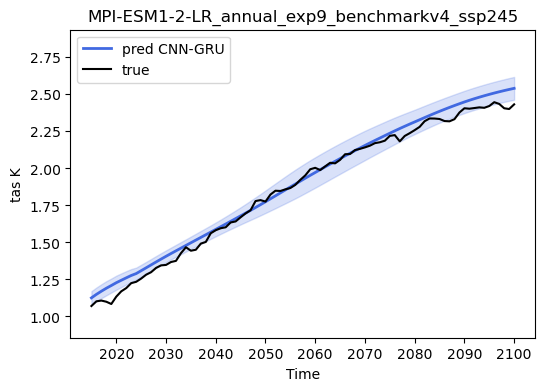

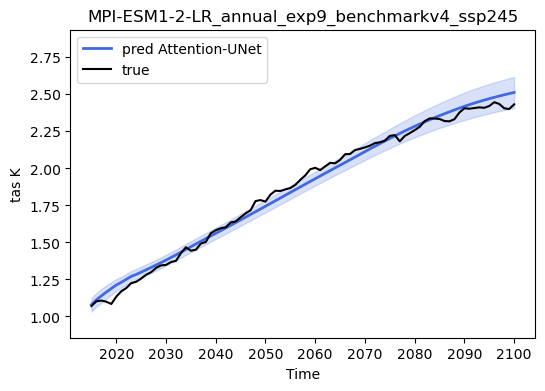

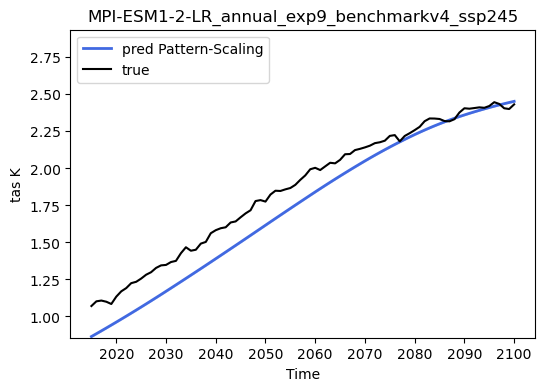

In [10]:
# clim changes 
for key, value in y_hat_dict.items():
    test_dict = {key:value}
    color_dict = {key: color}
    compare_temporal_profiles(y,
                              test_dict, 
                              t, 
                              var_name, 
                              lats, 
                              point=None, 
                              window_size=None, 
                              config_plots=config_plots, 
                              colors=color_dict, 
                              title=title, 
                              save_dir=save_dir)

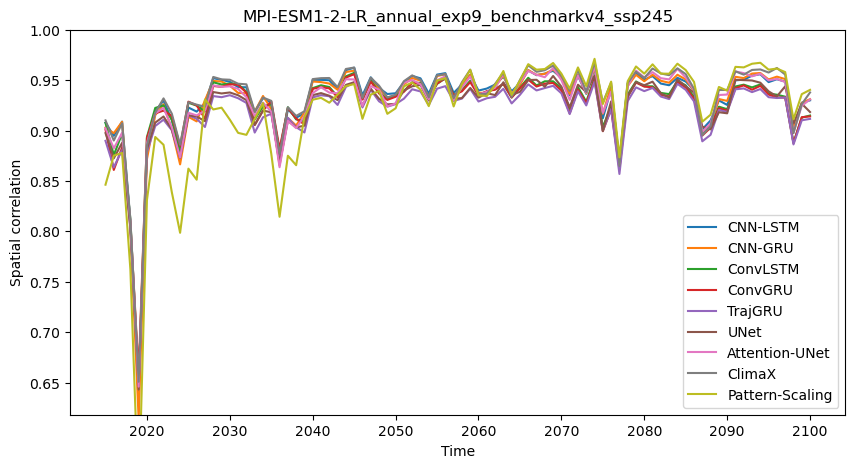

In [15]:
# Figure : Correlation spatiale

fig, ax1 = plt.subplots(figsize = (10,5))
for key, value in y_hat_dict.items():
    data = np.stack(value, axis=0)
    corr_list = []
    for run in range(data.shape[0]):
        data_seed = data[run]
        corr = [stats.pearsonr(y[i].flatten(), data_seed[i, ...].flatten()).statistic for i in range(y.shape[0])]
        corr_list.append(corr)
    corr_mean = np.stack(corr_list,axis=0).mean(axis=0)
    ax1.plot(t, corr_mean, label=key)
    ax1.set_title(title)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Spatial correlation')
    ax1.set_ylim(None,1)
ax1.legend()
if save_dir:
    fig.savefig(save_dir/f'{title}_spatial_correlation_{var_name}.png')

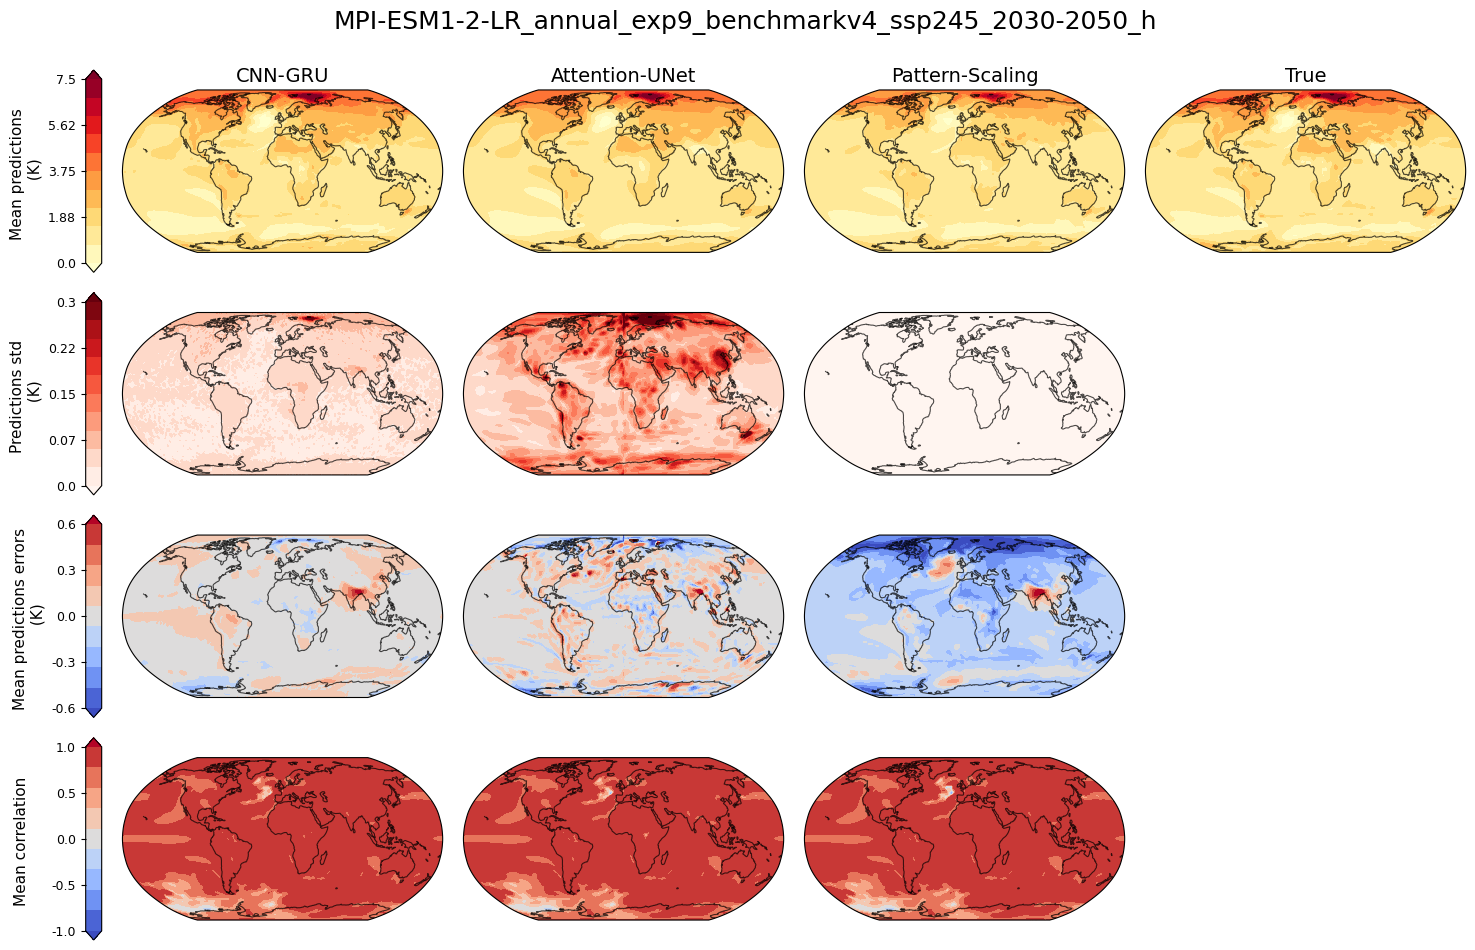

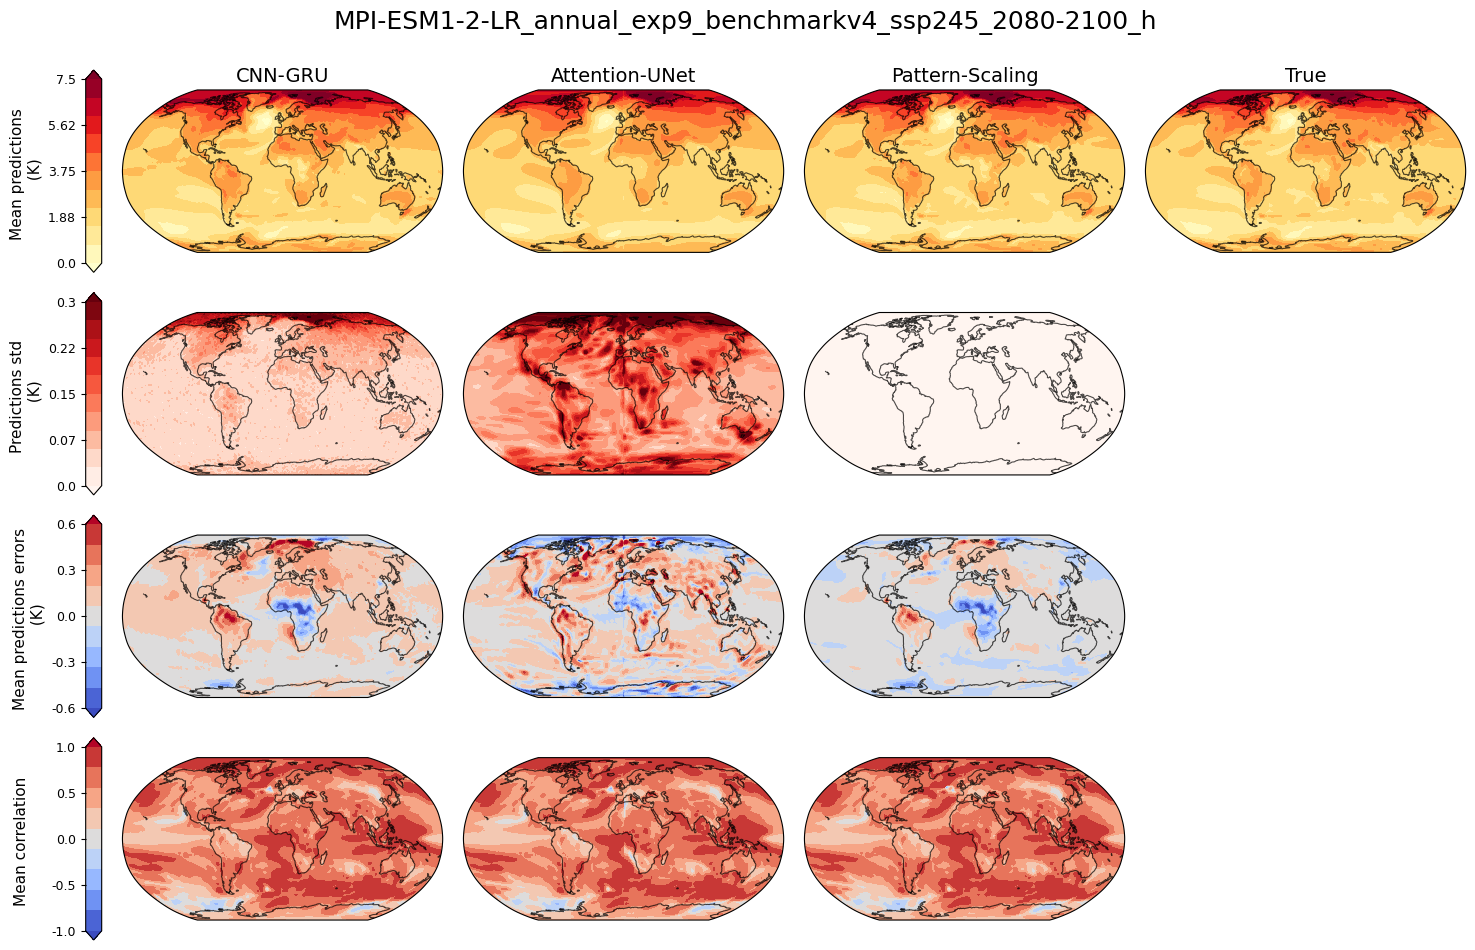

In [11]:

if var_name ==' tas':
    y_start = y[15:35, :, :]
    y_hat_dict_start = {}
    for key, y_hat in y_hat_dict.items():
        y_hat_dict_start[key] = [i[15:35,:,:] for i in y_hat]
    compare_metrics_maps(y_start, 
                        y_hat_dict_start, 
                        var_name=var_name, 
                        title=f'{title}_2030-2050_h', 
                        save_dir=save_dir,
                        config_plots=config_plots,
                        no_limits=False,
                        climatology=None,
                        relative_changes=relative_changes)

y_end = y[-21:, :, :]
y_hat_dict_end = {}
for key, y_hat in y_hat_dict.items():
    y_hat_dict_end[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics_maps(y_end, 
                    y_hat_dict_end, 
                    var_name=var_name, 
                    title=f'{title}_2080-2100_h', 
                    save_dir=save_dir,
                    config_plots=config_plots,
                    no_limits=False,
                    climatology=None,
                    relative_changes=relative_changes)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.1895368504179439, 0.21490472411866085, 0.7305808570223417] with 95% CI [[0.12762936635226826, 0.16208564864447103, 0.7305808570223417], [0.2666050485552289, 0.2575951877185731, 0.7305808570223417]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.05026177213518455, 0.10091030290124223, 0.15900238756281115] with 95% CI [[0.04143685104596363, 0.07017084488982121, 0.15900238756281115], [0.06361411178165553, 0.12635185880116762, 0.15900238756281115]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.027855015656547383, 0.022798884243483718, 0.1143156938919061] with 95% CI [[0.01723850306126093, 0.0167671740022009, 0.1143156938919061], [0.04059818735471467, 0.03085818887651652, 0.1143156938919061]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.07826906355185746, 0.1571403986626568, 0.24760304797010801] with 95% CI [[0.06452664500532082, 0.1092720388647869, 0.24760304797010801], [0.09906170726415596, 0.1967587143526331, 0.24760304797010801]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.04337662398365984, 0.03550307209553222, 0.1780156554395917] with 95% CI [[0.026844288100542662, 0.02611032106137449, 0.1780156554395917], [0.06322065401136122, 0.048053250883698

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.9942172765731812, 0.983810544013977, 0.9915227890014648] with 95% CI [[0.9935775399208069, 0.9765150547027588, 0.9915227890014648], [0.9948825240135193, 0.9905055165290833, 0.9915227890014648]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.2298111072116369, 0.2262792200549088, 0.11096617833903737] with 95% CI [[0.12620459091125982, 0.139667928365323, 0.11096617833903737], [0.3612092689196826, 0.3383497581986405, 0.11096617833903737]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.06555733010378122, 0.09916605977393467, 0.04183569085051854] with 95% CI [[0.05504495733164012, 0.0775637509404228, 0.04183569085051854], [0.08208616760684094, 0.11869861353548794, 0.04183569085051854]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.032850755421571134, 0.025422632056194827, 0.013826097497703764] with 95% CI [[0.01420327828977821, 0.011844065904541965, 0.013826097497703764], [0.05582462026256832, 0.04729457129211009, 0.013826097497703764]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.15545131379457494, 0.23514524235941026, 0.09920192137052393] with 95% CI [[0.13052409122555522, 0.1839212635327941, 0.09920192137052393], [0.19464494021712928, 0.28146136199

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.07789659953117804, 0.06028283255274943, 0.03278481624049496] with 95% CI [[0.03367919753352857, 0.02808496933319107, 0.03278481624049496], [0.13237284904924712, 0.11214616628027767, 0.03278481624049496]]
['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling'] = [0.9948192834854126, 0.9820378422737122, 0.9969359040260315] with 95% CI [[0.9932255148887634, 0.9720364809036255, 0.9969359040260315], [0.9964215159416199, 0.9887726306915283, 0.9969359040260315]]


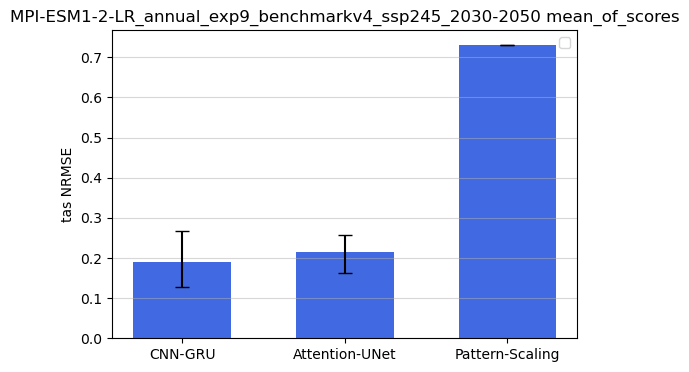

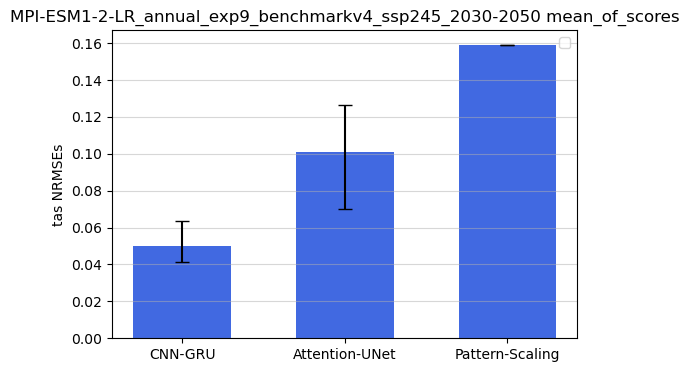

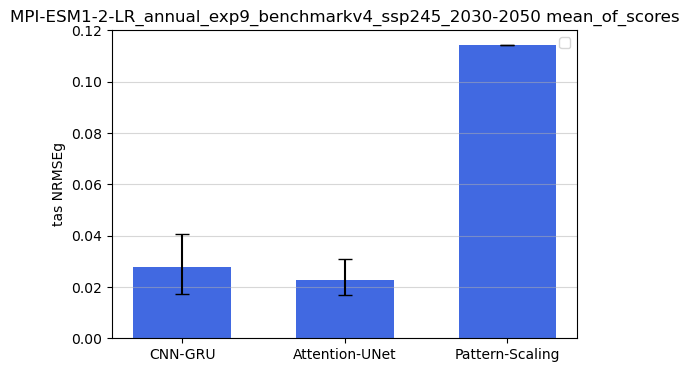

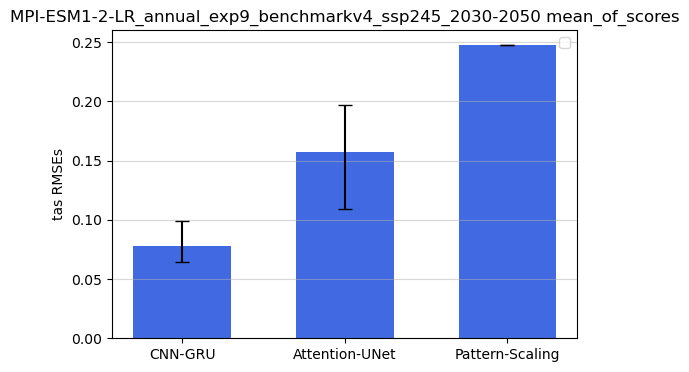

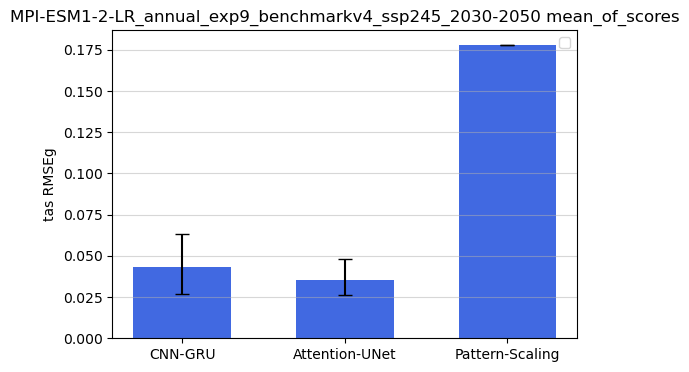

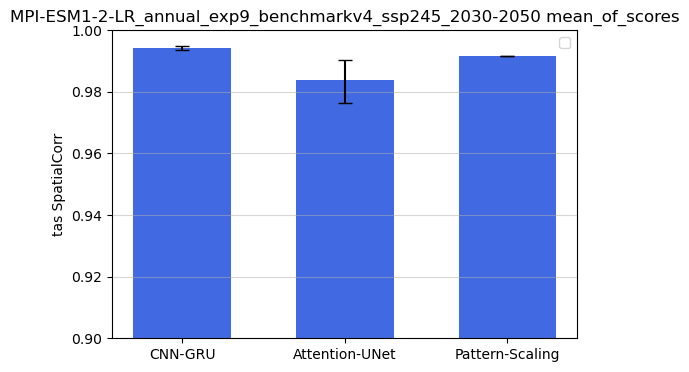

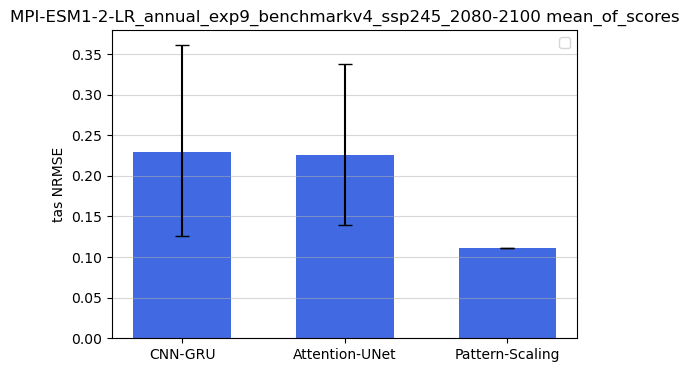

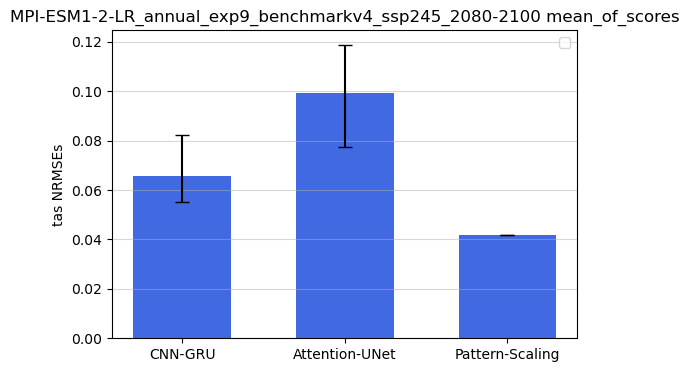

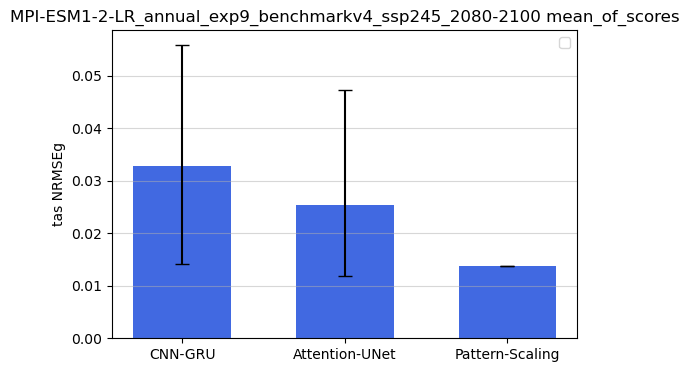

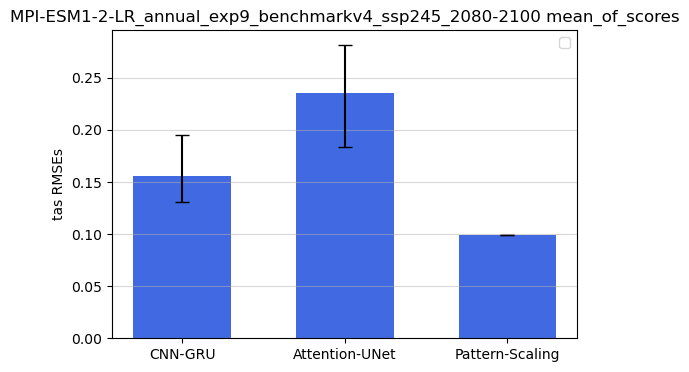

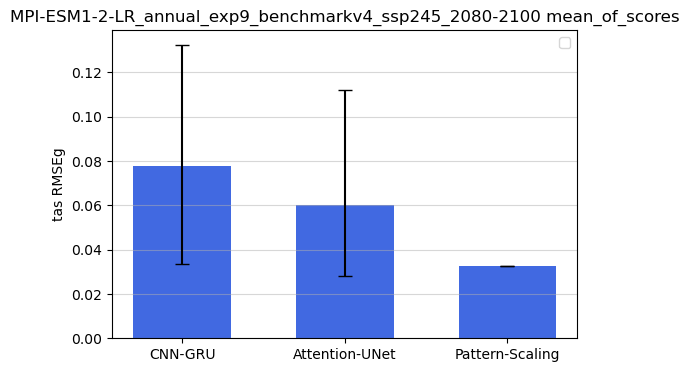

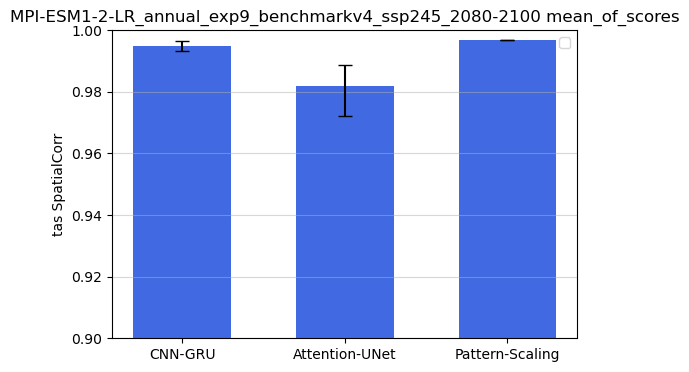

In [17]:
if var_name == 'tas':
    y_start = y[15:35, :, :] 
    y_hat_dict_start = {}
    for key, y_hat in y_hat_dict.items():
        y_hat_dict_start[key] = [i[15:35,:,:] for i in y_hat]
    compare_metrics(y_start, 
                y_hat_dict_start, 
                lats=lats, 
                var_name=var_name, 
                title=f'{title}_2030-2050', 
                save_dir=save_dir, 
                ensemble_scoring='mean_of_scores',
                figsize=(6,4),
                colors=color ,
                labels=None)

y_end = y[-21:, :, :] 
y_hat_dict_end = {}
for key, y_hat in y_hat_dict.items():
    y_hat_dict_end[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_end, 
            y_hat_dict_end, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2080-2100', 
            save_dir=save_dir, 
            ensemble_scoring='mean_of_scores',
            figsize=(6,4) if var_name=='tas' else (12,4),
            colors=color ,
            labels=None)

## Smoothing output data (LOWESS)

In [27]:
# Open true projection file
var_name = 'pr'

true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_ssp245.nc').mean('member') # 50 members
lats = true.lat.values
t = true.time.values
y = true[var_name].values

clim_simu = 'piControl'
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{clim_simu}.nc').mean('member')
if clim_simu == 'piControl':  
    clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')[var_name].values
else:
    clim = clim.sel(time=slice('1994-01-01', '2014-12-31')).mean('time')[var_name].values

y_hat_dict = {
        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'CNN-GRU LOWESS': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim_lowess0-1.nc')[var_name].values,  
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values,
        'Attention-UNet LOWESS' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_lowess0-1.nc')[var_name].values,
        'ConvLSTM' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'ConvLSTM LOWESS' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100_bs4_clim_lowess0-1.nc')[var_name].values,
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')[var_name].values}

y = y - clim
for test, y_hat in y_hat_dict.items():
    y_hat_dict[test] = y_hat - clim

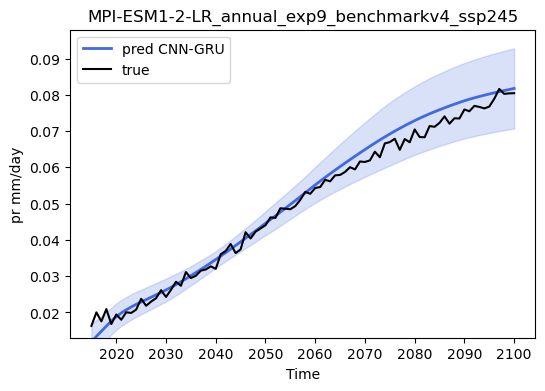

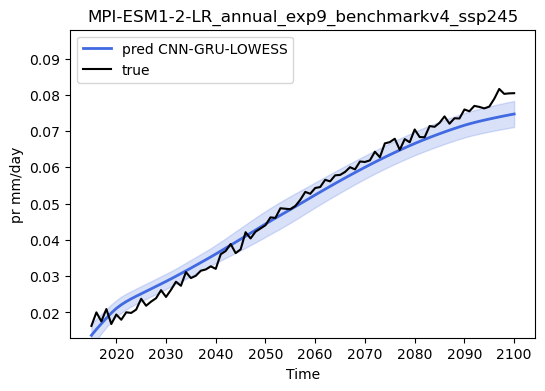

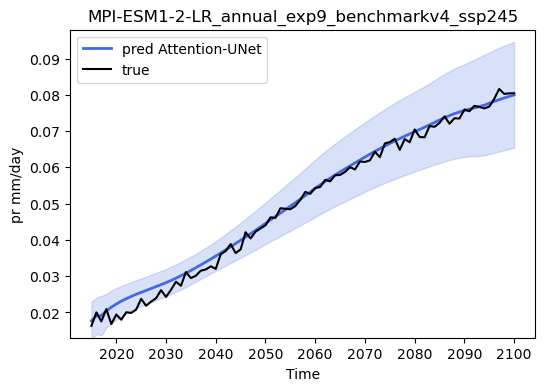

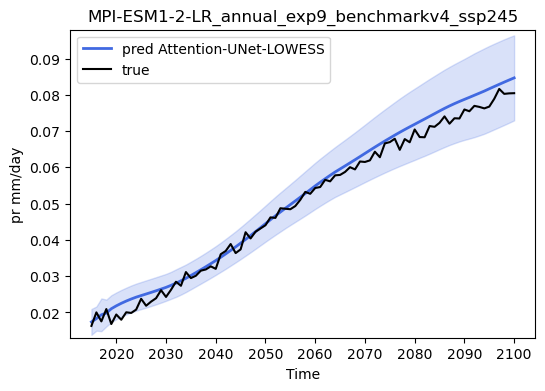

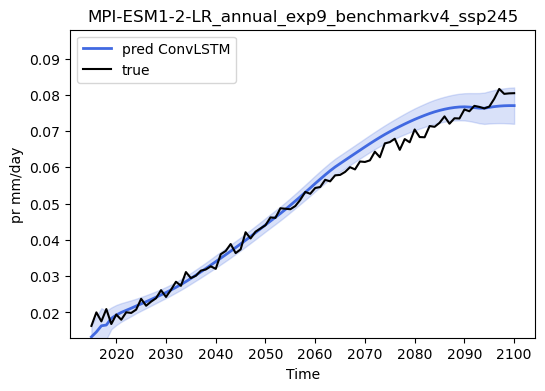

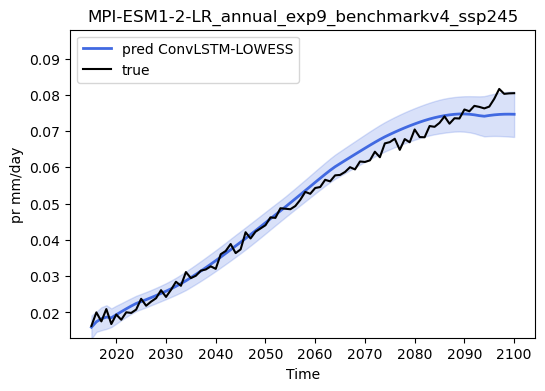

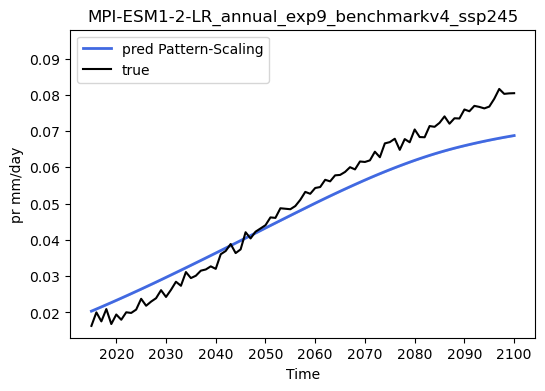

In [25]:
# clim changes 
for key, value in y_hat_dict.items():
    test_dict = {key:value}
    color_dict = {key: color}
    compare_temporal_profiles(y,
                              test_dict, 
                              t, 
                              var_name, 
                              lats, 
                              point=None, 
                              window_size=None, 
                              config_plots=config_plots, 
                              colors=color_dict, 
                              title=title, 
                              save_dir=save_dir)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [1.7956962117759177, 1.609056879105226, 1.5331066775595021, 1.5619602857507005, 1.620046415723514, 1.6301156355329005, 1.6910178504240252] with 95% CI [[1.3995215730269355, 1.4891865358737055, 1.1704108554216954, 1.2707279490670074, 1.4939636110671872, 1.5521247843866777, 1.6910178504240252], [2.3631790708859195, 1.7130969900875388, 2.179107119875096, 2.072319842899145, 1.7437907859223158, 1.708952237478468, 1.6910178504240252]]
['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [1.4440425499275098, 1.3277829709113391, 1.188130494313752, 1.1864822662983294, 1.37428879295905, 1.351148095781247, 1.0604891073445695] with 95% CI [[1.2679625553944927, 1.2541502267191922, 1.0321860218442718, 1.0845625501175067, 1.3031832335492768, 1.268848083869163, 1.0604891073445695], [1.6882647691946566, 1.538

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [0.10828112852637968, 0.09956343636522784, 0.08909163429246367, 0.08896804237366063, 0.10305066248237091, 0.10131546374780073, 0.07952048043111155] with 95% CI [[0.09507781916412371, 0.09404210554431806, 0.07739818144559711, 0.08132562083441873, 0.09771883190869685, 0.09514422027022987, 0.07952048043111155], [0.12659406363676898, 0.1153660887800199, 0.0976348828735188, 0.09534558303134105, 0.11188227097237124, 0.10788681775485098, 0.07952048043111155]]
['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [0.005273730383816041, 0.004218249137573997, 0.005173588609068082, 0.005631022948069457, 0.0036856133828234217, 0.004183660658483104, 0.00945600444701446] with 95% CI [[0.00180463907046146, 0.0020630293316691354, 0.0017757685802425483, 0.0018085991348066655, 0.002625730586094481, 0.0025821192

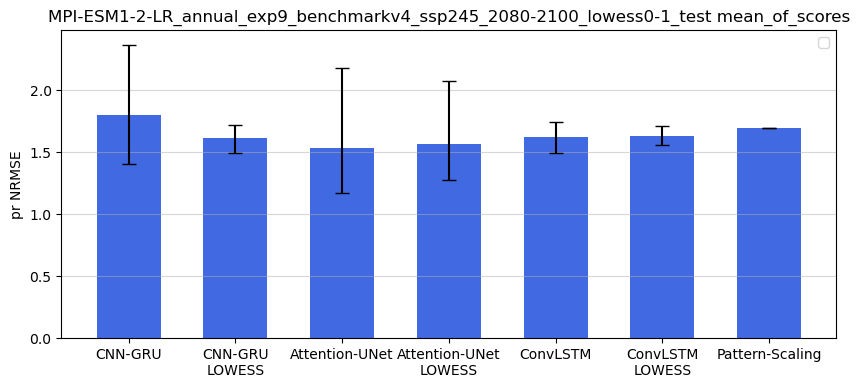

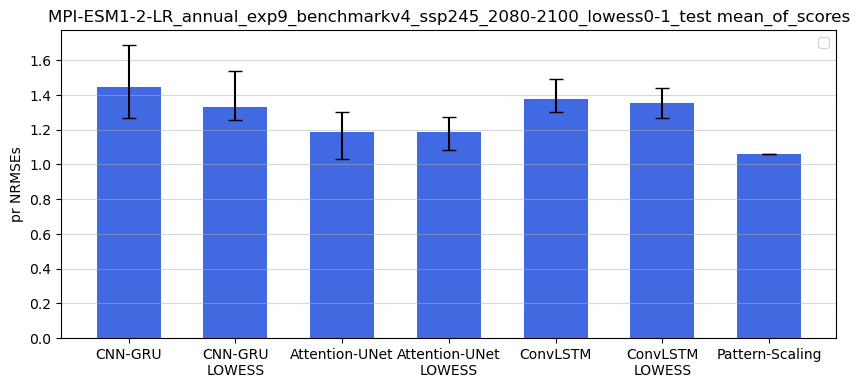

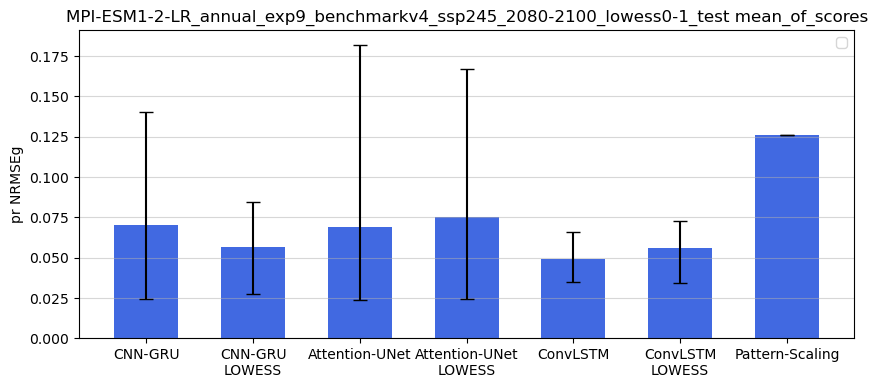

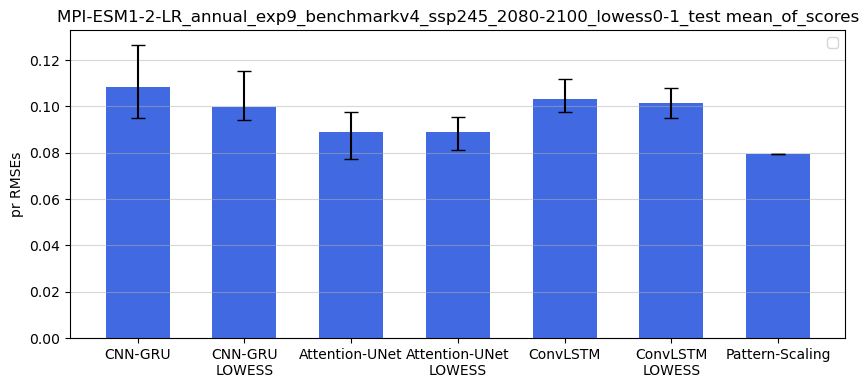

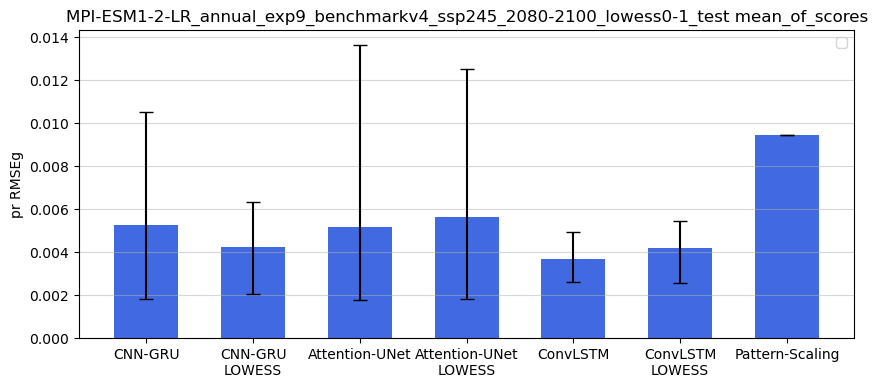

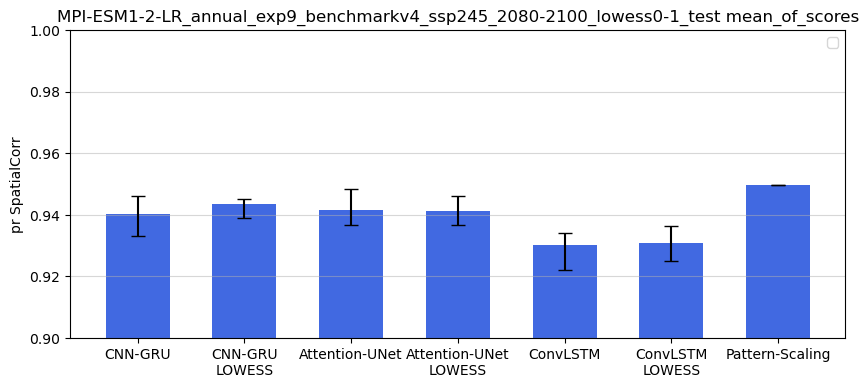

In [29]:
y_end = y[-21:, :, :]
y_hat_dict_end = {}
for key, y_hat in y_hat_dict.items():
    y_hat_dict_end[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_end, 
            y_hat_dict_end, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2080-2100_lowess0-1_test', 
            save_dir=save_dir, 
            ensemble_scoring='mean_of_scores',
            figsize=(10,4),
            colors=color ,
            labels=None)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [1.7937765525445264, 1.6057251884998363, 1.5222185165095676, 1.5534413494063428, 1.6121980554965387, 1.6203013273733913, 1.6870859364799955] with 95% CI [[1.3770965436756875, 1.48379655349891, 1.1457393046814366, 1.2470667271627798, 1.4849882793652653, 1.5397367783978804, 1.6870859364799955], [2.3670715308247003, 1.7107127964929982, 2.178178309743427, 2.0725796810438215, 1.7369063174737076, 1.7057520449518881, 1.6870859364799955]]
['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [1.449972507101183, 1.3362414569514218, 1.187463752348317, 1.185581430329799, 1.3726156542738857, 1.348085320380544, 1.0627313133009897] with 95% CI [[1.2677347864161526, 1.263184371796361, 1.0297161131816013, 1.0815236540713438, 1.301154210678989, 1.2648240885276483, 1.0627313133009897], [1.691386831463429, 1.545

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [0.10864645254061636, 0.10012458396588468, 0.08897666926881306, 0.08883562686362984, 0.10285010288692883, 0.10101204475541528, 0.07963046652851165] with 95% CI [[0.09499137854814474, 0.09465041594119315, 0.07715663729704487, 0.0810385767855228, 0.09749549629818813, 0.09477327993009874, 0.07963046652851165], [0.12673562996018342, 0.11582972841862361, 0.09787804146278536, 0.0955582277771989, 0.11145657802975947, 0.10787739514044714, 0.07963046652851165]]
['CNN-GRU', 'CNN-GRU LOWESS', 'Attention-UNet', 'Attention-UNet LOWESS', 'ConvLSTM', 'ConvLSTM LOWESS', 'Pattern-Scaling'] = [0.005152248021751701, 0.004038483668725156, 0.005016635476751497, 0.005512749385772419, 0.0035903822805638114, 0.004079429553277817, 0.00935657946664759] with 95% CI [[0.0014759489859705235, 0.0017865783255801369, 0.0014193360954773487, 0.001529908674610859, 0.002492158967379884, 0.002408943

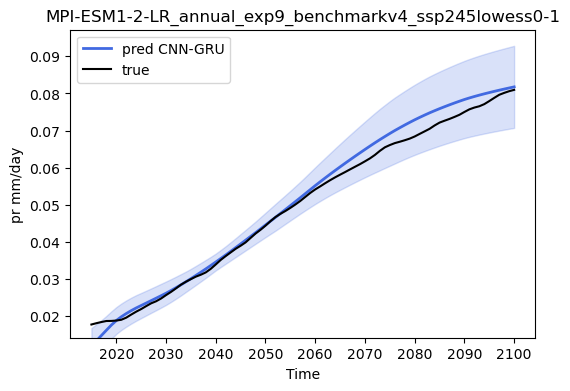

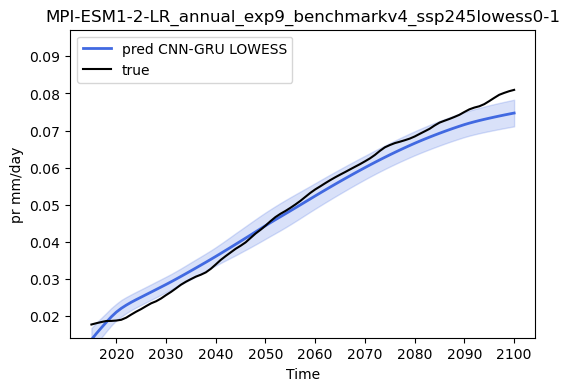

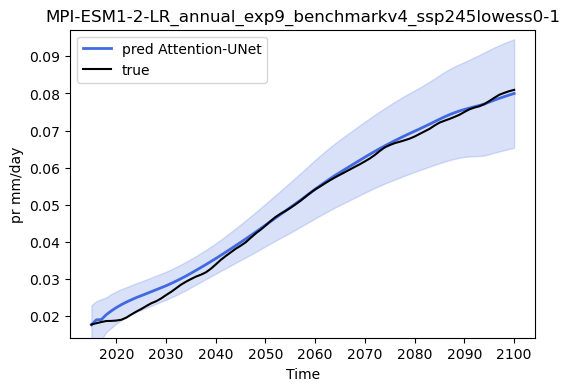

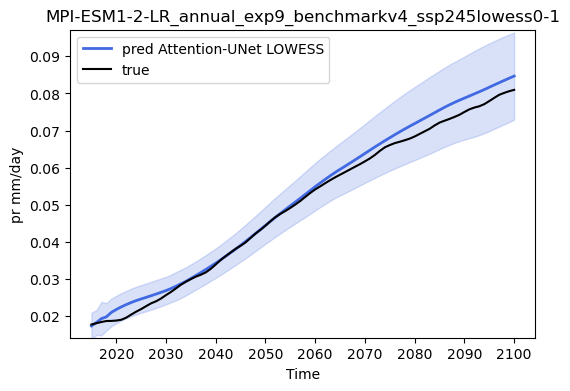

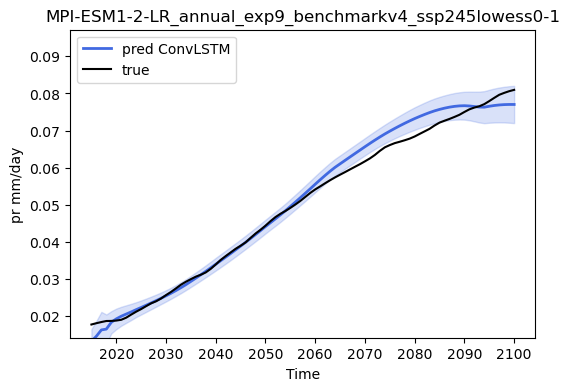

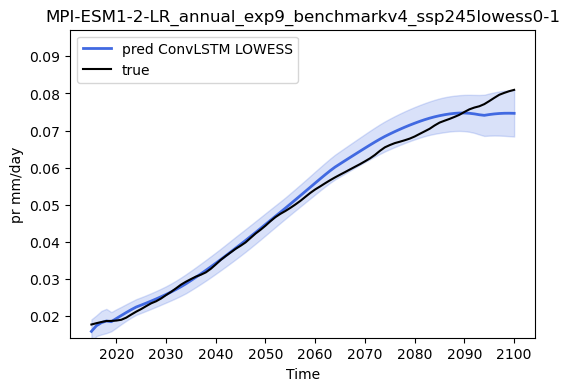

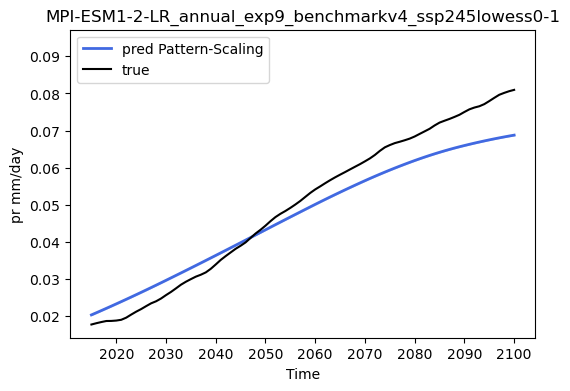

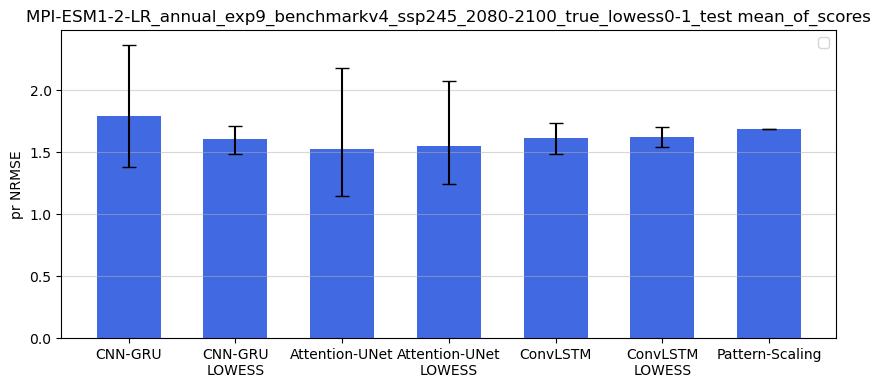

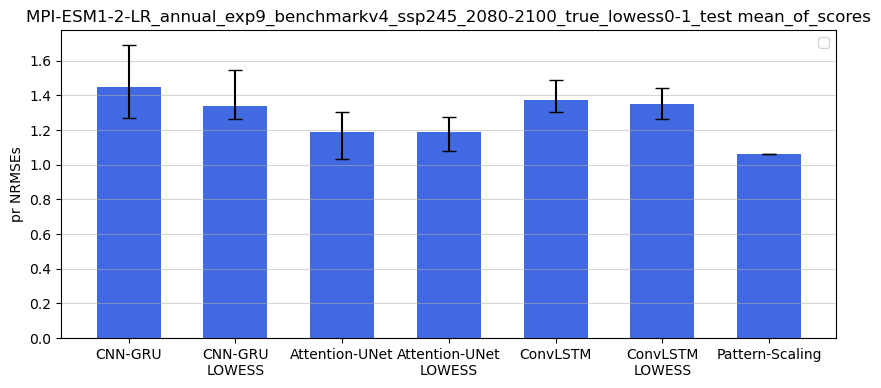

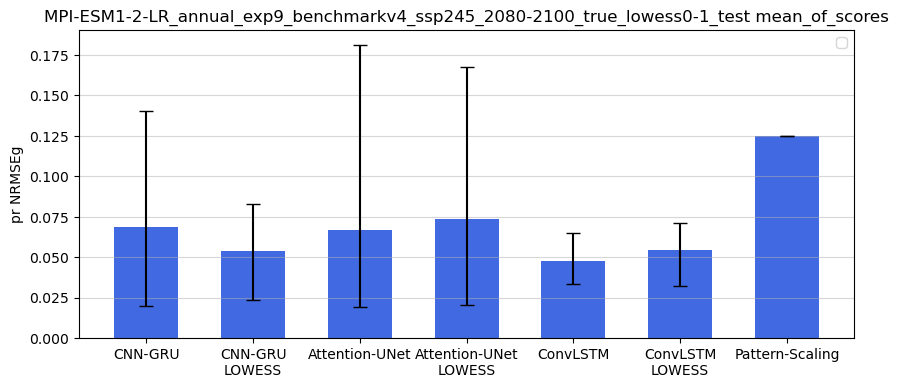

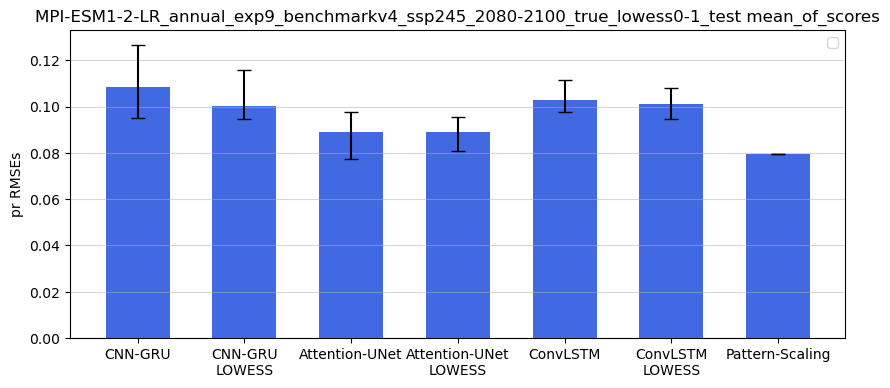

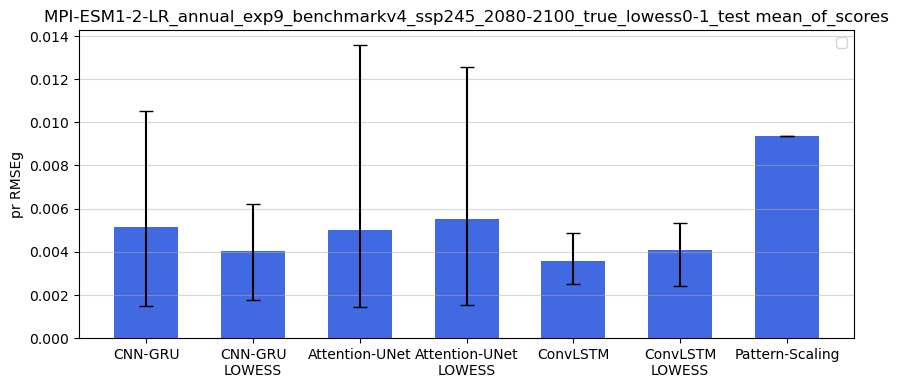

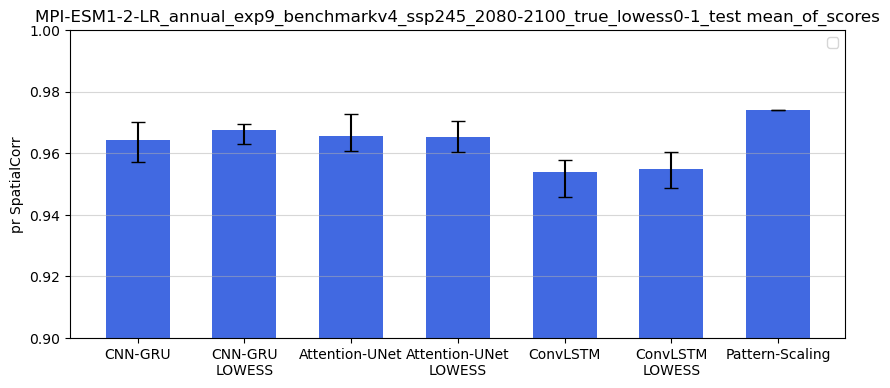

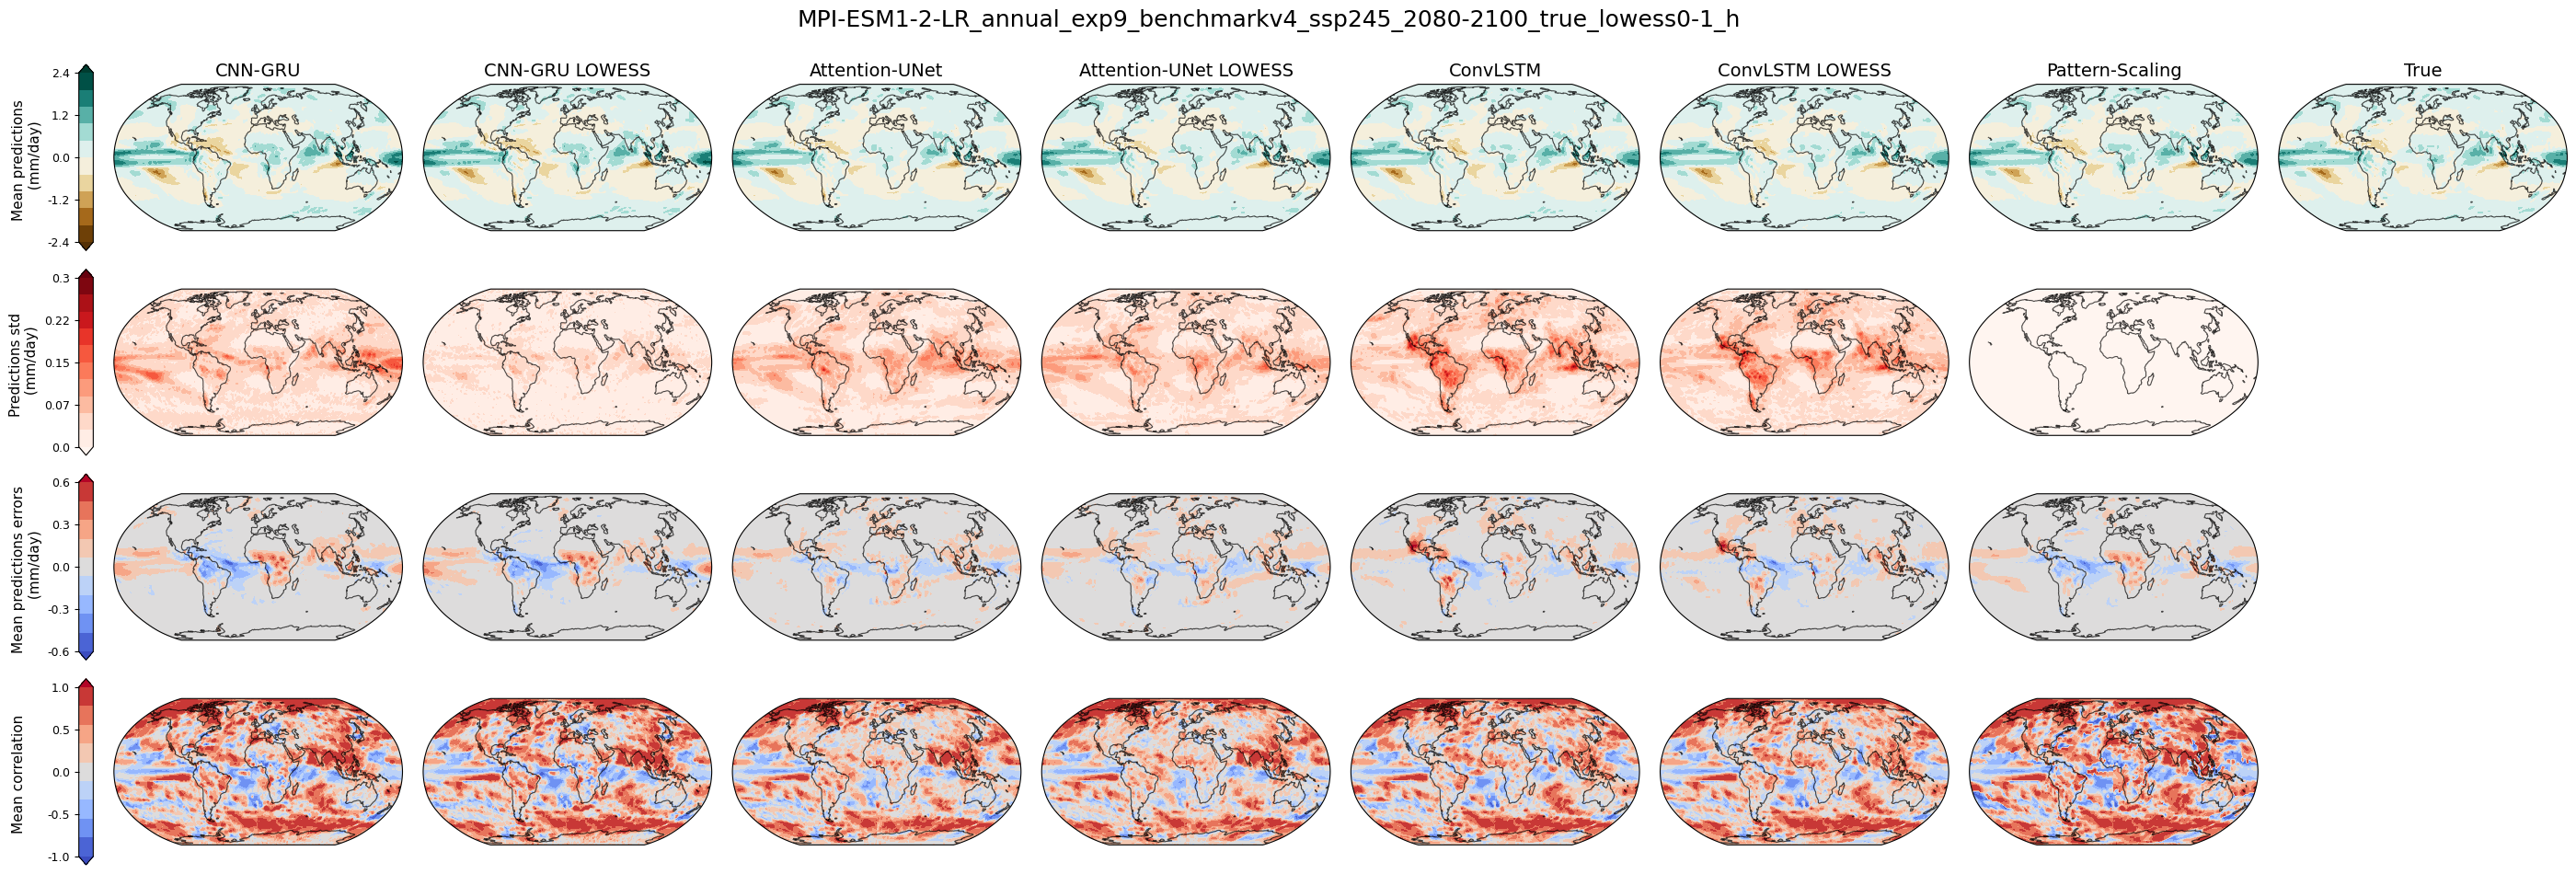

In [30]:
y_lowess = smooth_3Ddata(y, frac=0.1) # Compare with smoothed version of ssp245 forced response
for key, value in y_hat_dict.items():
    test_dict = {key:value}
    color_dict = {key: color}
    compare_temporal_profiles(y_lowess,
                              test_dict, 
                              t, 
                              var_name, 
                              lats, 
                              point=None, 
                              window_size=None, 
                              config_plots=config_plots, 
                              colors=color_dict, 
                              title=title + 'lowess0-1', 
                              save_dir=None)
y_lowess_end = y_lowess[-21:, :, :]
y_hat_dict_end = {}
for key, y_hat in y_hat_dict.items():
    y_hat_dict_end[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_lowess_end, 
            y_hat_dict_end, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2080-2100_true_lowess0-1_test', 
            save_dir=save_dir, 
            ensemble_scoring='mean_of_scores',
            figsize=(10,4),
            colors=color ,
            labels=None)

compare_metrics_maps(y_lowess_end, 
                    y_hat_dict_end, 
                    var_name=var_name, 
                    title=f'{title}_2080-2100_true_lowess0-1_h', 
                    save_dir=None,
                    config_plots=config_plots,
                    no_limits=False,
                    climatology=None,
                    relative_changes=relative_changes)